In [1]:
import pandas as pd
import seaborn as sns

In [2]:
insurance_data = pd.read_csv("dataset/insurance.csv")

In [3]:
insurance_data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


<Axes: xlabel='bmi', ylabel='charges'>

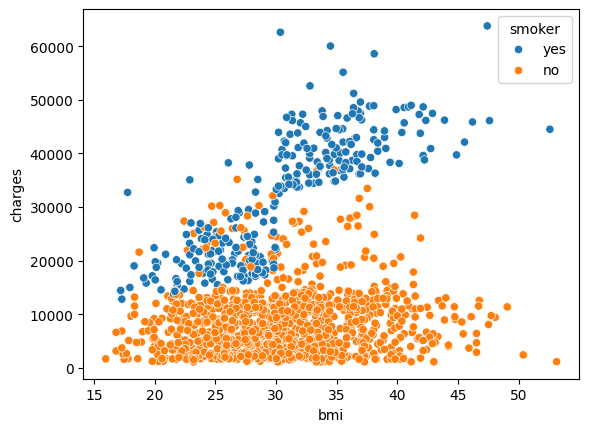

In [4]:
# visualize

sns.scatterplot(x = insurance_data["bmi"], y = insurance_data["charges"], hue = insurance_data["smoker"])

In [5]:
# preparing dataset for ml-

X = insurance_data.drop(columns = ["charges","region"])

y = insurance_data["charges"]

X["sex"] = X["sex"].map({ "female":1, "male" : 0} )
X["smoker"] = X["smoker"].map( {"yes" : 1, "no" : 0} )

In [6]:
X.head()

,age,sex,bmi,children,smoker
0,19,1,27.900,0,1
1,18,0,33.770,1,0
2,28,0,33.000,3,0
3,33,0,22.705,0,0
4,32,0,28.880,0,0


In [7]:
!pip install scikit-learn

In [8]:
# Train Test split --

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42)

In [9]:
X_test.head()

,age,sex,bmi,children,smoker
764,45,1,25.175,2,0
887,36,1,30.020,0,0
890,64,1,26.885,0,1
1293,46,0,25.745,3,0
259,19,0,31.920,0,1


In [10]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [11]:
y_pred = model.predict(X_test)

In [12]:
y_pred

array([ 8554.81711589,  6973.58746745, 36798.60416104,  9417.88282303,
       26871.68031081, 11097.38383938,   145.27608963, 16746.1683771 ,
         747.53414191, 11153.67590722, 28518.15016561,  9292.18345421,
        5460.51975119, 38510.48013003, 40359.30938604, 37223.40538064,
       15316.56711945, 36047.50032223,  9326.29049907, 31400.1559532 ,
        4269.64414373, 10464.66374097,  2719.9260555 ,  6579.53742551,
       11232.00255515, 12472.06793446, 14807.11281089,  6066.19283362,
        9535.69029723,  2377.6983797 ,  9475.05690885, 12963.23366722,
        4706.09057393,  3414.674504  ,  4815.64981654, 12484.17176954,
        2359.13614479,  9161.02061228, 33238.67621442, 32743.41702445,
        4274.58967205,  4229.5442107 , 14435.36485176, 11384.66898976,
        8925.70468583, 12480.09178788,  5154.45787816,  3554.10047649,
       35649.60942684,  9276.25523701, 15971.35991397,  2552.75200479,
       12162.99980138,  1062.65132285, 13551.43771934, 12103.65505529,
      

In [13]:
# Evaluation -

from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R-squ: ", r2)


n = X_test.shape[0]
p = X_test.shape[1]

adjusted_r2 = 1 - ( (1-r2) * (n-1) / (n-p-1) )
print("adjusted r2: ",adjusted_r2)


R-squ:  0.7811302113434095
adjusted r2:  0.7769533069797342


In [14]:
X_test.shape

(268, 5)

In [15]:
# One Hot Encoding- 

X = insurance_data.drop(columns = ["charges"])
y = insurance_data["charges"]

X = pd.get_dummies(X, columns = ["region"], drop_first=True, dtype=int)

X["sex"] = X["sex"].map({ "female":1, "male" : 0} )
X["smoker"] = X["smoker"].map( {"yes" : 1, "no" : 0} )

In [16]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42)


model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
print("r2 score: ",r2)

r2 score:  0.7835929767120724


In [17]:
# Interaction Features- 

X = insurance_data.drop(columns = ["charges"])
y = insurance_data["charges"]

X = pd.get_dummies(X, columns = ["region"], drop_first=True, dtype=int)

X["sex"] = X["sex"].map({ "female":1, "male" : 0} )
X["smoker"] = X["smoker"].map( {"yes" : 1, "no" : 0} )

X["age_smoker"] = X["age"] * X["smoker"]
X["bmi_smoker"] = X["bmi"] * X["smoker"]


In [18]:
X.head()

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest,age_smoker,bmi_smoker
0,19,1,27.900,0,1,0,0,1,19,27.9
1,18,0,33.770,1,0,0,1,0,0,0.0
2,28,0,33.000,3,0,0,1,0,0,0.0
3,33,0,22.705,0,0,1,0,0,0,0.0
4,32,0,28.880,0,0,1,0,0,0,0.0


In [19]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42)


model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
print("r2 score: ",r2)

r2 score:  0.865231697953168


In [20]:
# Underfit & Overfit --

# r2 training is low & r2 testing is also low -- underfit
# r2 training is veryy high & r2 testing is low -- overfit

y_train_pred = model.predict(X_train)
r2_train = r2_score(y_train, y_train_pred)

print("Training data: ", r2_train)
print("Test data ",r2)

Training data:  0.8340713711218875
Test data  0.865231697953168


In [21]:
# Lasso Regression --

from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error

MSE for 0.001 : 20922599.871035974
MSE for 0.1 : 20921803.69843139
MSE for 1 : 20914832.635089148
MSE for 2 : 20908106.779954527
MSE for 3 : 20901927.931570236
MSE for 4 : 20896130.81113566
MSE for 5 : 20890881.000633504
MSE for 10 : 20872844.794796687
MSE for 20 : 20877828.53237883
MSE for 30 : 20937537.13393977
MSE for 40 : 21046489.293890774
MSE for 50 : 21196929.869608898


<Axes: >

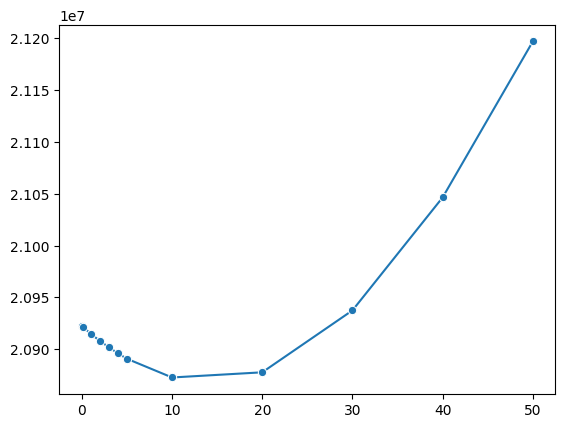

In [22]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42)


alphas = [0.001, 0.1, 1, 2, 3, 4, 5, 10, 20, 30, 40, 50]
mses = []

for a in alphas :
    lasso_model = Lasso(alpha = a)
    lasso_model.fit(X_train, y_train)
    
    y_pred = lasso_model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    print(f"MSE for {a} :",mse)
    mses.append(mse)

sns.lineplot(x = alphas, y = mses, marker = "o")

In [23]:
# Lasso_CV -
    # for cross validation :

from sklearn.linear_model import LassoCV

a = [0.001, 0.1, 1, 2, 3, 4, 5, 10, 20, 30, 40, 50]

lasso_cv_model =  LassoCV (
    alphas = a,
    cv = 5,
    max_iter = 1000,
    random_state = 42
)

lasso_cv_model.fit(X_train, y_train)

print("Best alpha: ", lasso_cv_model.alpha_)

Best alpha:  0.001


In [24]:

y_pred = lasso_cv_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print("r2 score: ",r2)
print("mse : ", mse)

r2 score:  0.8652317499151698
mse :  20922599.871035974


In [25]:
import pandas as pd
# ASSIGNMENT - 1

house_df = pd.read_csv("dataset/HousePricePrediction.csv")
house_df.head()

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0


In [26]:
house_df.info()
house_df.nunique()
house_df.sample(10)

<class 'pandas.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            2919 non-null   int64  
 1   MSSubClass    2919 non-null   int64  
 2   MSZoning      2915 non-null   str    
 3   LotArea       2919 non-null   int64  
 4   LotConfig     2919 non-null   str    
 5   BldgType      2919 non-null   str    
 6   OverallCond   2919 non-null   int64  
 7   YearBuilt     2919 non-null   int64  
 8   YearRemodAdd  2919 non-null   int64  
 9   Exterior1st   2918 non-null   str    
 10  BsmtFinSF2    2918 non-null   float64
 11  TotalBsmtSF   2918 non-null   float64
 12  SalePrice     1460 non-null   float64
dtypes: float64(3), int64(6), str(4)
memory usage: 296.6 KB


,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
2174,2174,60,RL,9720,CulDSac,1Fam,5,2001,2002,VinylSd,0.0,1357.0,NaN
2356,2356,20,RL,7441,Inside,1Fam,5,2006,2006,VinylSd,0.0,1461.0,NaN
1059,1059,50,RL,11275,Corner,1Fam,7,1932,1950,MetalSd,557.0,854.0,220000.0
2109,2109,30,RL,7111,Inside,1Fam,7,1928,1983,WdShing,273.0,1008.0,NaN
966,966,50,RL,9600,Inside,1Fam,7,1940,1950,MetalSd,0.0,728.0,160000.0
1477,1477,20,RL,11520,Inside,1Fam,5,2005,2005,VinylSd,0.0,1698.0,NaN
1301,1301,70,RL,7500,Inside,1Fam,7,1942,1950,Wd Sdng,0.0,771.0,177500.0
2684,2684,60,RL,12585,Inside,1Fam,5,1993,1993,HdBoard,1039.0,1286.0,NaN
2410,2410,20,RL,9770,Inside,1Fam,5,1957,1957,Wd Sdng,0.0,922.0,NaN
2545,2545,20,RL,8240,Inside,1Fam,6,1960,1960,HdBoard,0.0,1179.0,NaN


<Axes: xlabel='LotArea', ylabel='SalePrice'>

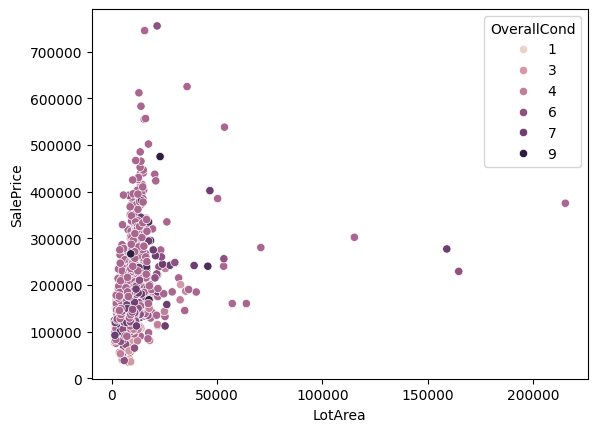

In [27]:
import seaborn as sns

sns.scatterplot(x = house_df["LotArea"], y = house_df["SalePrice"] , hue = house_df["OverallCond"])

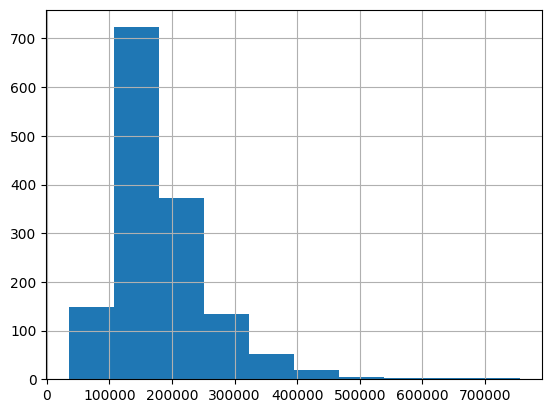

In [28]:
import matplotlib.pyplot as plt

house_df["SalePrice"].hist()
plt.show()

In [29]:
corr = house_df.corr(numeric_only=True)

print(
    corr["SalePrice"]
    .sort_values(ascending=False)
    .head(15)
)

SalePrice       1.000000
TotalBsmtSF     0.613581
YearBuilt       0.522897
YearRemodAdd    0.507101
LotArea         0.263843
BsmtFinSF2     -0.011378
Id             -0.021917
OverallCond    -0.077856
MSSubClass     -0.084284
Name: SalePrice, dtype: float64


In [30]:

house_df = house_df[house_df["SalePrice"].notnull()]

X = house_df.drop(columns=["SalePrice", "Id"])
y = house_df["SalePrice"]

X["HouseAge"] = 2026 - house_df["YearBuilt"]
X["RemodelAge"] = 2026 - X["YearRemodAdd"]
X["TotalArea"] = X["LotArea"] + X["TotalBsmtSF"]
X["BsmtRatio"] = X["TotalBsmtSF"] / X["LotArea"]

X = pd.get_dummies(
    X,
    drop_first=True,
    dtype=int
)

num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

for col in num_cols:
    X[col] = X[col].fillna(X[col].median())

for col in cat_cols:
    X[col] = X[col].fillna(X[col].mode()[0])


In [31]:
print(y.head())
print(X.sample(5))
# X.isnull().sum().sort_values(ascending=False)

# corr = X.corr(numeric_only=True)
# print(corr["SalePrice"].sort_values(ascending=False))

0    208500.0
1    181500.0
2    223500.0
3    140000.0
4    250000.0
Name: SalePrice, dtype: float64
      MSSubClass  LotArea  OverallCond  YearBuilt  YearRemodAdd  BsmtFinSF2  \
637          190     6000            4       1954          1954         0.0   
755          160     3230            5       1999          1999         0.0   
1269          50    11344            5       1958          1958         0.0   
1142          60     9965            5       2006          2007         0.0   
730          120     5389            5       1995          1996         0.0   

      TotalBsmtSF  HouseAge  RemodelAge  TotalArea  ...  Exterior1st_CemntBd  \
637         811.0        72          72     6811.0  ...                    0   
755         729.0        27          27     3959.0  ...                    0   
1269        874.0        68          68    12218.0  ...                    0   
1142       1466.0        20          19    11431.0  ...                    0   
730        1595.0      

In [32]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)


# y_train = y_train.fillna(y_train.mean())

print(y_train.isnull().sum())
print(y_train.mean())

0
181441.5419520548


In [33]:

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [34]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R-squ: ", r2)


R-squ:  0.645953438318577
